# Error Rate Forecasting with CatBoost (Stratified Split)
Прогнозирование error_rate на 2-3 минуты с правильным разбиением данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/error_rate_dataset.csv')
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nError rate stats:\n{df['error_rate'].describe()}")
print(f"\nNull values: {df['error_rate'].isna().sum()} (строки с NaN из деления на 0 уже отброшены при сборе)")


Shape: (24329, 2)

Columns: ['timestamp', 'error_rate']

Error rate stats:
count    24329.000000
mean         0.030661
std          0.025280
min          0.015804
25%          0.025285
50%          0.027557
75%          0.029814
max          0.421890
Name: error_rate, dtype: float64

Null values: 0 (строки с NaN из деления на 0 уже отброшены при сборе)


In [2]:
# 2-3 minutes = 8-12 points (at 15-second intervals)
FORECAST_HORIZON = 10  # 10 * 15 sec = 2.5 minutes

# Create lagged features
# Для error_rate используем чуть более длинные лаги — метрика инерционнее CPU
def create_features(df, horizon=FORECAST_HORIZON, lags=[1, 2, 3, 4, 5, 8, 12, 16, 20, 24]):
    df = df.copy()

    # Lag features
    for lag in lags:
        df[f'er_lag_{lag}'] = df['error_rate'].shift(lag)

    # Rolling statistics
    for window in [4, 8, 12, 20]:
        df[f'er_rolling_mean_{window}'] = df['error_rate'].rolling(window).mean()
        df[f'er_rolling_std_{window}']  = df['error_rate'].rolling(window).std()
        df[f'er_rolling_min_{window}']  = df['error_rate'].rolling(window).min()
        df[f'er_rolling_max_{window}']  = df['error_rate'].rolling(window).max()

    # Дополнительные признаки для error_rate
    # Скорость изменения (первая разность)
    df['er_diff_1'] = df['error_rate'].diff(1)
    df['er_diff_2'] = df['error_rate'].diff(2)

    # Экспоненциальное скользящее среднее
    df['er_ewm_4']  = df['error_rate'].ewm(span=4,  adjust=False).mean()
    df['er_ewm_12'] = df['error_rate'].ewm(span=12, adjust=False).mean()

    # Target: error_rate value in FORECAST_HORIZON steps
    df['er_target'] = df['error_rate'].shift(-horizon)

    return df

df_features = create_features(df, horizon=FORECAST_HORIZON)
print(f"Features created. Shape: {df_features.shape}")


Features created. Shape: (24329, 33)


In [3]:
# Remove rows with NaN values
df_clean = df_features.dropna().reset_index(drop=True)
print(f"After removing NaN: {df_clean.shape}")
print(f"Removed {df_features.shape[0] - df_clean.shape[0]} rows")

# Extract hour from timestamp for stratified split
df_clean['hour'] = pd.to_datetime(df_clean['timestamp'], unit='s').dt.hour

# Stratified train/test split by hour (80/20, preserve temporal order within each hour)
hours = df_clean['hour'].unique()
train_dfs = []
test_dfs  = []

print(f"\n🎯 Stratified split by hour:")
print(f"{'Hour':>6} {'Total':>8} {'Train':>8} {'Test':>8}")
print("-" * 40)

for hour in sorted(hours):
    hour_data = df_clean[df_clean['hour'] == hour].reset_index(drop=True)
    split_idx = int(len(hour_data) * 0.8)
    train_dfs.append(hour_data[:split_idx])
    test_dfs.append(hour_data[split_idx:])
    print(f"{hour:>6} {len(hour_data):>8} {split_idx:>8} {len(hour_data)-split_idx:>8}")

df_train = pd.concat(train_dfs, ignore_index=True).sort_values('timestamp').reset_index(drop=True)
df_test  = pd.concat(test_dfs,  ignore_index=True).sort_values('timestamp').reset_index(drop=True)

print("-" * 40)
print(f"{'TOTAL':>6} {len(df_clean):>8} {len(df_train):>8} {len(df_test):>8}")
print(f"Split ratio: {len(df_train)/len(df_clean)*100:.1f}% / {len(df_test)/len(df_clean)*100:.1f}%")


After removing NaN: (24295, 33)
Removed 34 rows

🎯 Stratified split by hour:
  Hour    Total    Train     Test
----------------------------------------
     0      964      771      193
     1      960      768      192
     2      960      768      192
     3      960      768      192
     4      960      768      192
     5      960      768      192
     6      964      771      193
     7      960      768      192
     8      960      768      192
     9      960      768      192
    10      960      768      192
    11      960      768      192
    12      964      771      193
    13      960      768      192
    14      960      768      192
    15      960      768      192
    16      960      768      192
    17      960      768      192
    18     1012      809      203
    19     1200      960      240
    20     1200      960      240
    21     1200      960      240
    22     1200      960      240
    23     1191      952      239
--------------------------------

In [4]:
# Feature selection
feature_cols = [col for col in df_clean.columns
                if col.startswith('er_') and col not in ('er_target',)]

X_train = df_train[feature_cols]
y_train = df_train['er_target']

X_test = df_test[feature_cols]
y_test = df_test['er_target']

print(f"Features ({len(feature_cols)}):")
for f in feature_cols:
    print(f"  {f}")
print(f"\nTrain set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")


Features (30):
  er_lag_1
  er_lag_2
  er_lag_3
  er_lag_4
  er_lag_5
  er_lag_8
  er_lag_12
  er_lag_16
  er_lag_20
  er_lag_24
  er_rolling_mean_4
  er_rolling_std_4
  er_rolling_min_4
  er_rolling_max_4
  er_rolling_mean_8
  er_rolling_std_8
  er_rolling_min_8
  er_rolling_max_8
  er_rolling_mean_12
  er_rolling_std_12
  er_rolling_min_12
  er_rolling_max_12
  er_rolling_mean_20
  er_rolling_std_20
  er_rolling_min_20
  er_rolling_max_20
  er_diff_1
  er_diff_2
  er_ewm_4
  er_ewm_12

Train set: (19434, 30)
Test set:  (4861, 30)


In [5]:
# Detailed analysis of stratified splits
print("\n" + "="*80)
print("DETAILED ANALYSIS OF STRATIFIED TRAIN/TEST DATA SPLITS")
print("="*80)

print("\n📊 SIZE COMPARISON:")
print(f"  Train size: {len(df_train):,} samples ({len(df_train)/len(df_clean)*100:.1f}%)")
print(f"  Test size:  {len(df_test):,} samples ({len(df_test)/len(df_clean)*100:.1f}%)")

print("\n⏰ TEMPORAL COVERAGE:")
from datetime import datetime
train_start = datetime.fromtimestamp(df_train['timestamp'].min())
train_end   = datetime.fromtimestamp(df_train['timestamp'].max())
test_start  = datetime.fromtimestamp(df_test['timestamp'].min())
test_end    = datetime.fromtimestamp(df_test['timestamp'].max())

print(f"  Train: {train_start} → {train_end}")
print(f"         ({(train_end - train_start).total_seconds()/3600:.1f} hours)")
print(f"  Test:  {test_start} → {test_end}")
print(f"         ({(test_end - test_start).total_seconds()/3600:.1f} hours)")

print("\n📈 ERROR RATE STATISTICS:")
print(f"  {'':20} {'Train':>14} {'Test':>14} {'Diff':>14}")
for stat_name, tr_val, te_val in [
    ('Mean',   df_train['error_rate'].mean(),   df_test['error_rate'].mean()),
    ('Median', df_train['error_rate'].median(), df_test['error_rate'].median()),
    ('Min',    df_train['error_rate'].min(),    df_test['error_rate'].min()),
    ('Max',    df_train['error_rate'].max(),    df_test['error_rate'].max()),
    ('Std Dev',df_train['error_rate'].std(),    df_test['error_rate'].std()),
]:
    print(f"  {stat_name:<20} {tr_val:>14.4f} {te_val:>14.4f} {te_val-tr_val:>+14.4f}")

print("\n🏷️  HOUR DISTRIBUTION:")
print(f"{'Hour':>6} {'Train':>10} {'Test':>10} {'Train %':>10} {'Test %':>10}")
for hour in sorted(df_clean['hour'].unique()):
    tc = len(df_train[df_train['hour'] == hour])
    ec = len(df_test[df_test['hour'] == hour])
    print(f"{hour:>6} {tc:>10,} {ec:>10,} {tc/len(df_train)*100:>10.1f}% {ec/len(df_test)*100:>10.1f}%")

print("\n" + "="*80)



DETAILED ANALYSIS OF STRATIFIED TRAIN/TEST DATA SPLITS

📊 SIZE COMPARISON:
  Train size: 19,434 samples (80.0%)
  Test size:  4,861 samples (20.0%)

⏰ TEMPORAL COVERAGE:
  Train: 2026-05-25 21:48:00 → 2026-05-29 21:09:15
         (95.4 hours)
  Test:  2026-05-29 02:58:00 → 2026-05-30 02:57:30
         (24.0 hours)

📈 ERROR RATE STATISTICS:
                                Train           Test           Diff
  Mean                         0.0309         0.0296        -0.0013
  Median                       0.0277         0.0271        -0.0006
  Min                          0.0158         0.0161        +0.0003
  Max                          0.4219         0.1264        -0.2954
  Std Dev                      0.0276         0.0120        -0.0156

🏷️  HOUR DISTRIBUTION:
  Hour      Train       Test    Train %     Test %
     0        771        193        4.0%        4.0%
     1        768        192        4.0%        3.9%
     2        768        192        4.0%        3.9%
     3        7

In [6]:
# Train CatBoost model
# Для error_rate используем RMSE — штрафует за редкие спайки ошибок сильнее MAE
train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function='RMSE',
    eval_metric='MAE',
    verbose=100,
    random_state=42,
    task_type='CPU'
)

model.fit(train_pool, eval_set=test_pool)


0:	learn: 0.0067619	test: 0.0065644	best: 0.0065644 (0)	total: 62ms	remaining: 30.9s
100:	learn: 0.0023389	test: 0.0031516	best: 0.0031361 (98)	total: 386ms	remaining: 1.52s
200:	learn: 0.0020987	test: 0.0031968	best: 0.0031361 (98)	total: 710ms	remaining: 1.06s
300:	learn: 0.0019375	test: 0.0032475	best: 0.0031361 (98)	total: 1.03s	remaining: 679ms
400:	learn: 0.0018306	test: 0.0032764	best: 0.0031361 (98)	total: 1.44s	remaining: 355ms
499:	learn: 0.0017534	test: 0.0033002	best: 0.0031361 (98)	total: 1.76s	remaining: 0us

bestTest = 0.003136133928
bestIteration = 98

Shrink model to first 99 iterations.


CatBoostRegressor(depth=7, eval_metric='MAE', iterations=500, learning_rate=0.05, loss_function='RMSE', random_state=42, task_type='CPU', verbose=100)

In [7]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# Clip predictions: error_rate не может быть < 0 или > 1
y_pred_train = np.clip(y_pred_train, 0, 1)
y_pred_test  = np.clip(y_pred_test,  0, 1)

def evaluate(y_true, y_pred, set_name=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE: пропускаем точки с нулевым фактическим значением
    nonzero_mask = y_true != 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    else:
        mape = float('nan')
    r2 = r2_score(y_true, y_pred)

    print(f"{set_name}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAPE: {mape:.2f}% (только ненулевые точки)")
    print(f"  R\u00b2:   {r2:.4f}")
    return mae, rmse, mape, r2

print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
train_metrics = evaluate(y_train.values, y_pred_train, '📊 Train Set')
print()
test_metrics  = evaluate(y_test.values,  y_pred_test,  '📊 Test Set')
print("="*50)

print("\n🔍 Analysis:")
mae_diff = test_metrics[0] - train_metrics[0]
if abs(mae_diff) < 0.005:
    print(f"  ✓ Excellent generalization! (MAE difference: {mae_diff:+.6f})")
elif abs(mae_diff) < 0.01:
    print(f"  ✓ Good generalization (MAE difference: {mae_diff:+.6f})")
elif mae_diff > 0.01:
    print(f"  ⚠ Slight overfitting (MAE difference: {mae_diff:+.6f})")
else:
    print(f"  ⚠ Test better than train? (MAE diff: {mae_diff:+.6f})")


MODEL PERFORMANCE METRICS
📊 Train Set
  MAE:  0.002347
  RMSE: 0.005449
  MAPE: 7.07% (только ненулевые точки)
  R²:   0.9611

📊 Test Set
  MAE:  0.003137
  RMSE: 0.007169
  MAPE: 8.92% (только ненулевые точки)
  R²:   0.6424

🔍 Analysis:
  ✓ Excellent generalization! (MAE difference: +0.000790)


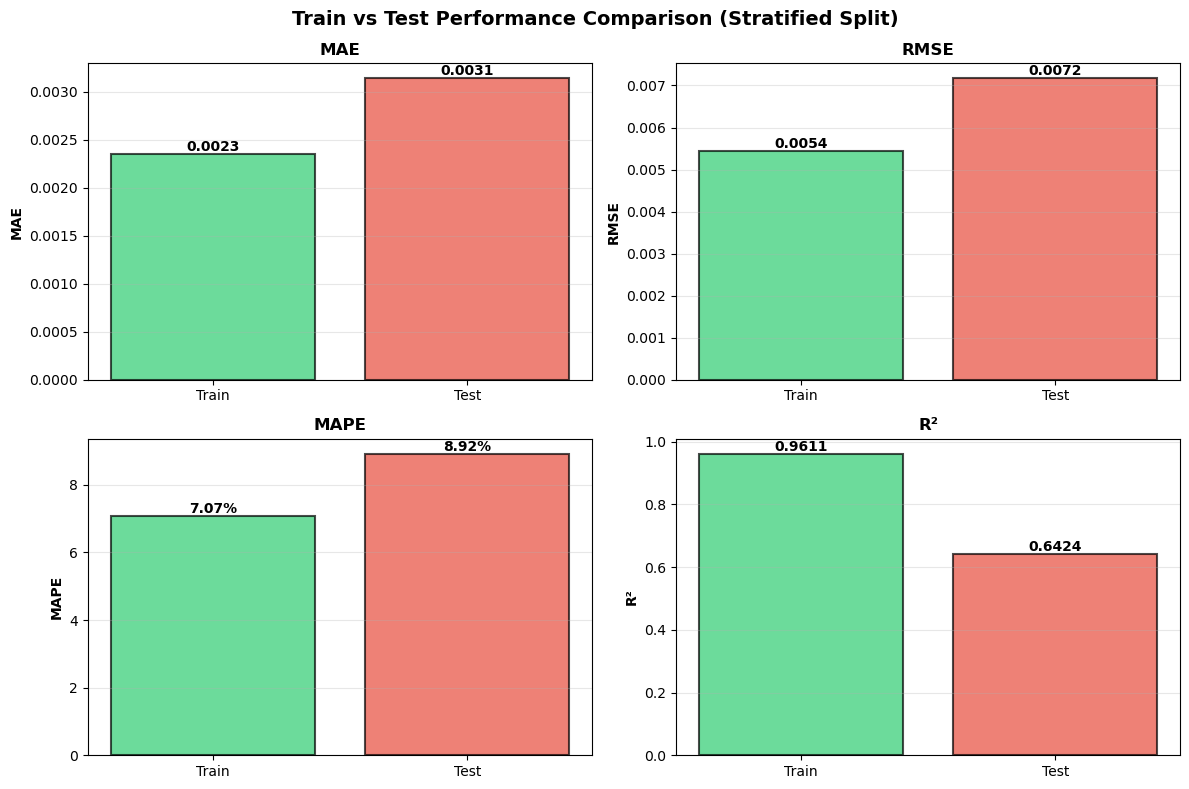


METRICS COMPARISON TABLE
Metric                    Train            Test      Difference
----------------------------------------------------------------------
MAE                    0.002347        0.003137       +0.000790
RMSE                   0.005449        0.007169       +0.001720
MAPE (%)                 7.0715          8.9163         +1.8448
R²                       0.9611          0.6424         -0.3187


In [8]:
# Comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Train vs Test Performance Comparison (Stratified Split)', fontsize=14, fontweight='bold')

metrics = {
    'MAE':  (train_metrics[0], test_metrics[0]),
    'RMSE': (train_metrics[1], test_metrics[1]),
    'MAPE': (train_metrics[2], test_metrics[2]),
    'R\u00b2':   (train_metrics[3], test_metrics[3])
}

positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
colors = ['#2ecc71', '#e74c3c']

for (metric_name, (train_val, test_val)), (i, j) in zip(metrics.items(), positions):
    ax = axes[i, j]
    bars = ax.bar(['Train', 'Test'], [train_val, test_val],
                  color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric_name, fontweight='bold')
    ax.set_title(metric_name, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}' if metric_name != 'MAPE' else f'{height:.2f}%',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("METRICS COMPARISON TABLE")
print("="*70)
print(f"{'Metric':<15} {'Train':>15} {'Test':>15} {'Difference':>15}")
print("-"*70)
print(f"{'MAE':15} {train_metrics[0]:>15.6f} {test_metrics[0]:>15.6f} {test_metrics[0]-train_metrics[0]:>+15.6f}")
print(f"{'RMSE':15} {train_metrics[1]:>15.6f} {test_metrics[1]:>15.6f} {test_metrics[1]-train_metrics[1]:>+15.6f}")
print(f"{'MAPE (%)':15} {train_metrics[2]:>15.4f} {test_metrics[2]:>15.4f} {test_metrics[2]-train_metrics[2]:>+15.4f}")
print(f"{'R\u00b2':15} {train_metrics[3]:>15.4f} {test_metrics[3]:>15.4f} {test_metrics[3]-train_metrics[3]:>+15.4f}")
print("="*70)



Top 15 Important Features:
          feature  importance
        er_diff_2   19.742338
        er_diff_1   13.667080
         er_lag_1   12.653129
 er_rolling_std_4    8.974792
 er_rolling_max_4    7.607265
         er_lag_2    7.543486
 er_rolling_std_8    6.020045
 er_rolling_min_4    4.625639
er_rolling_mean_4    3.184285
         er_ewm_4    2.911032
er_rolling_max_20    2.695794
        er_lag_24    1.361363
        er_lag_12    1.306498
er_rolling_std_12    1.082254
er_rolling_std_20    1.050977


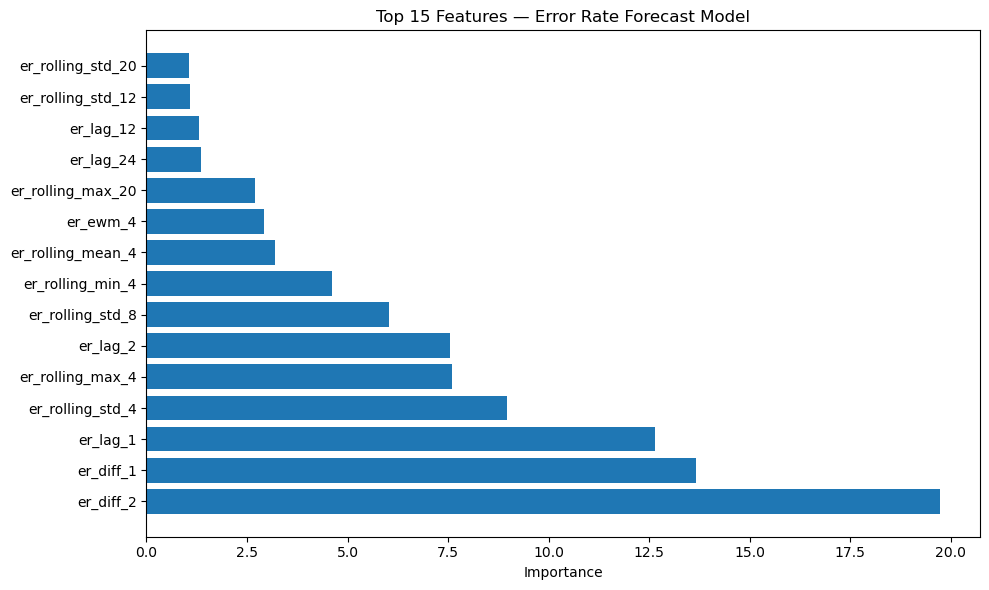

In [9]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Features — Error Rate Forecast Model')
plt.tight_layout()
plt.show()


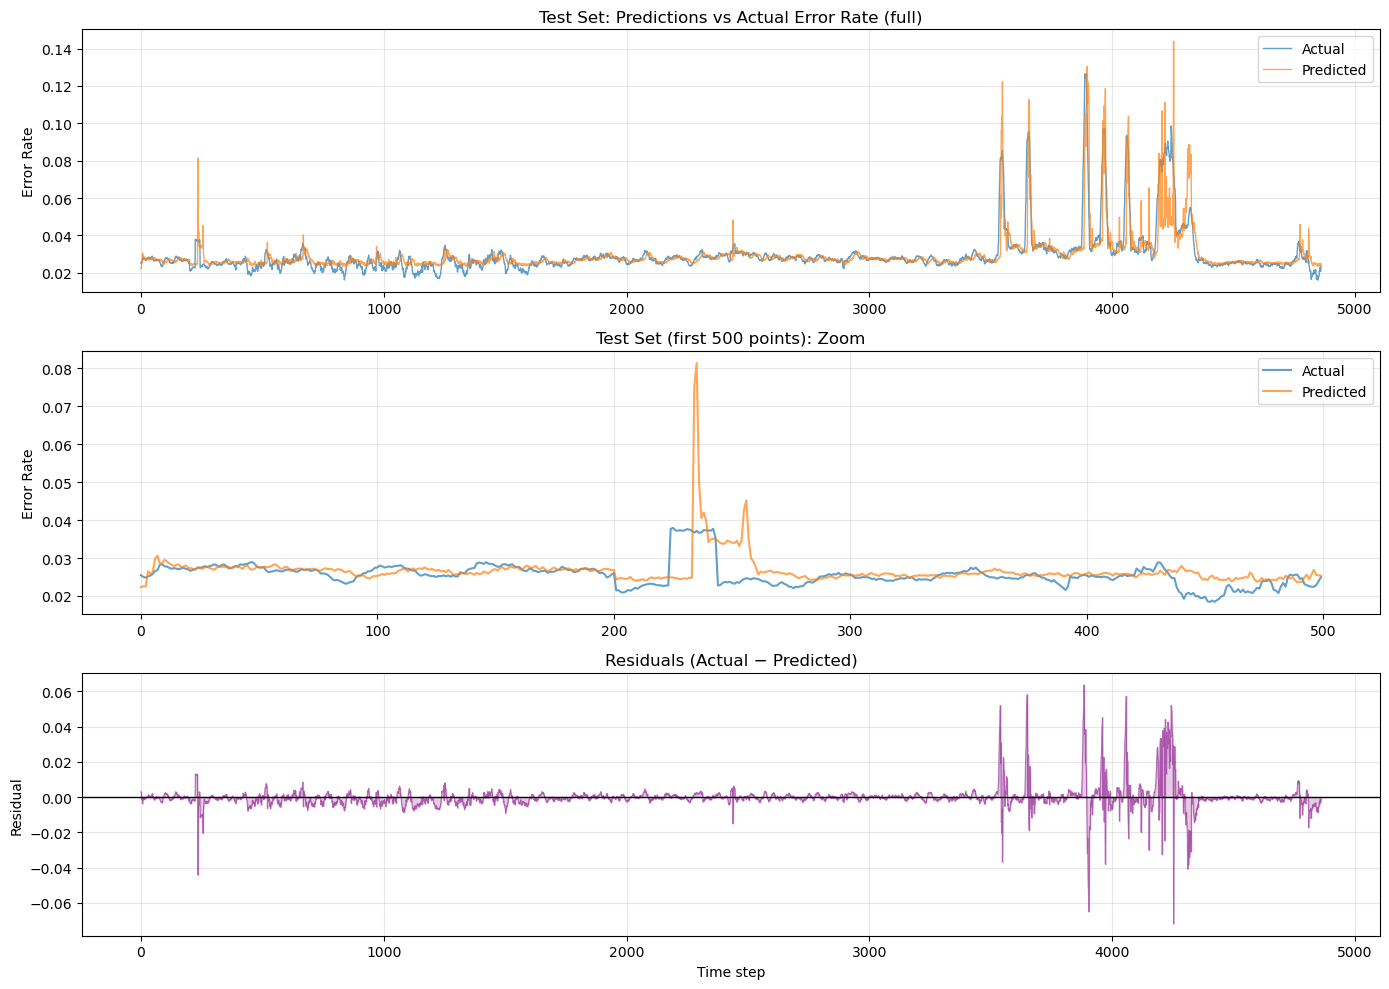


Prediction error distribution (test set):
  Min error:       0.000000
  Median error:    0.001412
  Max error:       0.071895
  95th percentile: 0.010893


In [10]:
# Visualization: predictions vs actual
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Full test set
test_range = range(len(y_test))
axes[0].plot(test_range, y_test.values,  label='Actual',    alpha=0.7, linewidth=1.0)
axes[0].plot(test_range, y_pred_test,    label='Predicted', alpha=0.7, linewidth=1.0)
axes[0].set_title('Test Set: Predictions vs Actual Error Rate (full)')
axes[0].set_ylabel('Error Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoom: first 500 points
zoom_n = min(500, len(y_test))
axes[1].plot(range(zoom_n), y_test.values[:zoom_n], label='Actual',    alpha=0.7, linewidth=1.5)
axes[1].plot(range(zoom_n), y_pred_test[:zoom_n],   label='Predicted', alpha=0.7, linewidth=1.5)
axes[1].set_title(f'Test Set (first {zoom_n} points): Zoom')
axes[1].set_ylabel('Error Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Residuals
residuals = y_test.values - y_pred_test
axes[2].plot(test_range, residuals, alpha=0.5, linewidth=0.8, color='purple')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].fill_between(test_range, residuals, 0, alpha=0.2, color='purple')
axes[2].set_title('Residuals (Actual − Predicted)')
axes[2].set_xlabel('Time step')
axes[2].set_ylabel('Residual')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrediction error distribution (test set):")
errors = np.abs(y_test.values - y_pred_test)
print(f"  Min error:       {errors.min():.6f}")
print(f"  Median error:    {np.median(errors):.6f}")
print(f"  Max error:       {errors.max():.6f}")
print(f"  95th percentile: {np.percentile(errors, 95):.6f}")


In [11]:
# Save model
model.save_model('../models/error_rate_forecast_model.cbm')
print("Model saved as 'error_rate_forecast_model.cbm'")

import json
with open('../models/error_rate_model_config.json', 'w') as f:
    json.dump({
        'feature_cols': feature_cols,
        'forecast_horizon': FORECAST_HORIZON,
        'lag_features': [1, 2, 3, 4, 5, 8, 12, 16, 20, 24],
        'rolling_windows': [4, 8, 12, 20],
        'extra_features': ['er_diff_1', 'er_diff_2', 'er_ewm_4', 'er_ewm_12']
    }, f, indent=2)
print("Config saved as 'error_rate_model_config.json'")


Model saved as 'error_rate_forecast_model.cbm'
Config saved as 'error_rate_model_config.json'
